# NBA Game Outcome Prediction Model

*Ashay Patla*

*INFO-629*

### Introduction

**Dataset:**

NBA Odds Data (Kaggle): https://www.kaggle.com/datasets/christophertreasure/nba-odds-data?resource=download

**Description:**

With the growth of sports betting over the last couple years, there is a large volume
of historical betting and game data. This project uses that historical data to train a machine
learning model to predict future games. Past betting data including predicted point totals, odds
for a team to win, actual outcome, and spread to train a model. The model will learn patterns
between sportsbook predictions and actual outcomes. Given user inputs including parameters
such as home team, away team, spread, odds, and predicted total, the model would output a
percentage confidence in indicating a team to win.

**Use Case / Stakeholders:**

* Sports Bettors
    * Model predictions could be used to identify value bets where probability predictions beat implied odds. 
* Sportsbooks / Betting Platforms
    * Can utilize the model to evaluate market efficiency improve their own models.
* Media Analyst
    * Can gain deeper insights into game probabilities and team performance.

### Preprocessing

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay

In [42]:
#import data and review columns
df = pd.read_csv("oddsData.csv")
df.head()

,date,season,team,home/visitor,opponent,score,opponentScore,moneyLine,opponentMoneyLine,total,spread,secondHalfTotal
0,2007-10-30,2008,Utah,@,Golden State,117,96,100.0,-120.0,212.0,1.0,105.5
1,2007-10-30,2008,LA Lakers,vs,Houston,93,95,190.0,-230.0,199.0,5.0,99.0
2,2007-10-30,2008,Houston,@,LA Lakers,95,93,-230.0,190.0,199.0,-5.0,99.0
3,2007-10-30,2008,San Antonio,vs,Portland,106,97,-1400.0,900.0,189.5,-13.0,95.0
4,2007-10-30,2008,Portland,@,San Antonio,97,106,900.0,-1400.0,189.5,13.0,95.0


#### Step 1: Normalize Games to Home Team 

To simplify model training and ensure consistency, all game data was standardized from the perspective of the home team. This allows the model to use a single set of team based features and streamlines processing.



In [43]:
#convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

#seperate home and away rows
home = df[df["home/visitor"].str.strip().str.lower() == 'vs'].copy()
away = df[df["home/visitor"].str.strip() == '@'].copy()

#rename columns in terms of home and away
home = home.rename(columns={
    "moneyLine": "home_ml",
    "spread": "home_spread",
    "score": "home_score",
    "opponentScore": "away_score"
})

away = away.rename(columns={
    "moneyLine": "away_ml"
})

#merge home and away so all games are in terms of home
games = home.merge(
    away[["date", "team", "away_ml"]],
    left_on=["date", "opponent"],
    right_on=["date", "team"],
    how= "inner"
)


#create column to mark 0 or 1 for home win
games["home_win"] = (games["home_score"] > games["away_score"]).astype(int)

games.head()

,date,season,team_x,home/visitor,opponent,home_score,away_score,home_ml,opponentMoneyLine,total,home_spread,secondHalfTotal,team_y,away_ml,home_win
0,2007-10-30,2008,LA Lakers,vs,Houston,93,95,190.0,-230.0,199.0,5.0,99.0,Houston,-230.0,0
1,2007-10-30,2008,San Antonio,vs,Portland,106,97,-1400.0,900.0,189.5,-13.0,95.0,Portland,900.0,1
2,2007-10-30,2008,Golden State,vs,Utah,96,117,-120.0,100.0,212.0,-1.0,105.5,Utah,100.0,0
3,2007-10-31,2008,New Jersey,vs,Chicago,112,103,-125.0,105.0,186.0,-1.5,94.0,Chicago,105.0,1
4,2007-10-31,2008,Cleveland,vs,Dallas,74,92,120.0,-140.0,184.0,2.5,91.5,Dallas,-140.0,0


#### Step 2: Adding Season Phases

Since features from sportsbooks provided limited additional signal, season phases were introduced to capture how information evolves over the season. As the season progreses both sportsbooks and teams become more predictable, leading to more accurate estimates by the end of the season


In [44]:
#add season phase - add another input for regression (1=early, 2=middle, 3=late)

#count number of games per season (some seasons had less due to contract disputes)
games["season_game_number"] = games.groupby("season").cumcount()
#max games per season
max_games = games.groupby("season")["season_game_number"].transform("max")
#normalize all season game numbers
games["season_progress"] = games["season_game_number"]/max_games
#split into thirds
games["season_phase"] = pd.cut(
    games["season_progress"],
    bins=[-0.000000001, 1/3, 2/3, 1],
    labels=[1,2,3]
).astype(int)



#### Step 3: Remove Older Season

Sportsbooks have improved over the past few years so by only training the model on the most recent seasons. Seasons that are incomplete such as 2020 (COVID year) and 2023 (Dataset ended halfway through the season) were removed. 2023 was saved as a season to test on.

In [45]:
#remove older seasons
test_season = games[games["season"] == 2023].copy()
games = games[(games["season"] >= 2017) & (games["season"] < 2023) & (games["season"] != 2020)].copy()

#### Step 4: Testing Efficency of Sportsbooks

Reviewing if sportsbooks get more efficient later in the season. With more games played.

In [46]:
games["home_favorite"] = (games["home_spread"] < 0).astype(int)

favorite_win = (
    games[games["home_favorite"] == 1]
    .groupby("season_phase")["home_win"]
    .mean())

favorite_win

season_phase
1    0.674381
2    0.694268
3    0.708871
Name: home_win, dtype: float64

In [47]:
underdog_win = (
    games[games["home_favorite"] == 0]
    .groupby("season_phase")["home_win"]
    .mean()
)

underdog_lose = 1 - underdog_win
underdog_lose

season_phase
1    0.622490
2    0.623989
3    0.661842
Name: home_win, dtype: float64

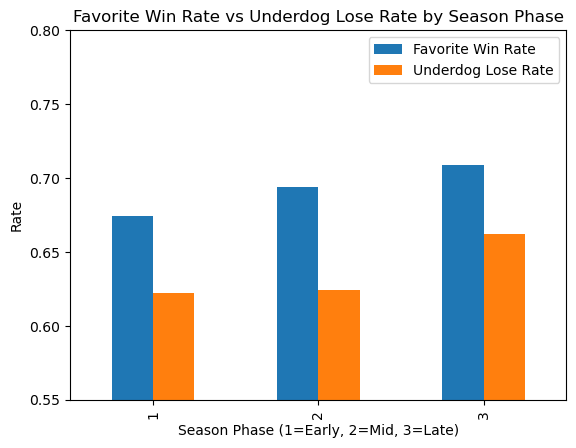

In [48]:
phase_accuracy = pd.DataFrame({
    "Favorite Win Rate": favorite_win,
    "Underdog Lose Rate": underdog_lose
})

phase_accuracy.plot(kind="bar")

plt.title("Favorite Win Rate vs Underdog Lose Rate by Season Phase")
plt.xlabel("Season Phase (1=Early, 2=Mid, 3=Late)")
plt.ylabel("Rate")
plt.ylim(0.55, 0.80) 

plt.show()

This shows how as the season enters the third stage the favorite win rate and underdog lose rate increase, showing season phase to be a factor in sports book accuracy when deciding favorites and underdogs. 

#### Step 5: Seperate Modeling Features & One Hot Encoding

Seperate the features needed for training and one hot encode season phase to convert it into a binary representation.

**Input Variables:**
* Spread
    * Positive or negative value representing the predicted point difference between teams (typically -10 to +10
* Total
    * Projected combined point total for the game (typically 200+)
* Season Phase (One Hot Encoded)
    * Categorical variables representing when the game occurs in season

**Target Variable:**
* Binary variable “home_win” where:
    * 1 = Home team win
    * 0 = Home team loss


In [49]:
#seperate modeling data
df_model = games[["season", "home_spread", "total", "season_phase", "home_win"]].copy()

#one-hot encode season phases (season 1 becomes the baseline)
df_model = pd.get_dummies(df_model, columns=["season_phase"], drop_first=True)

df_model

,season,home_spread,total,home_win,season_phase_2,season_phase_3
10822,2017,-9.0,206.0,1,False,False
10823,2017,-8.0,212.0,0,False,False
10824,2017,-5.5,192.0,1,False,False
10825,2017,-11.5,212.5,1,False,False
10826,2017,1.5,195.0,0,False,False
...,...,...,...,...,...,...
17786,2022,-9.0,227.0,0,False,True
17787,2022,-10.0,225.5,1,False,True
17788,2022,0.0,214.0,1,False,True
17789,2022,17.0,220.0,0,False,True


### Modeling

**Why Logistic Regression**

Logistic regression was chosen because it models a binary outcome (win/loss), can be used to produce win probabilities, can handle multiple inputs and allows for comparison between sportsbook odds. 

#### Step 1: Walk Forward Validation

Since it is possible that sportsbooks could have improved over the years or had bad predictive seasons, I utilized walk forward validation to test the stability of the model over the 4 seasons being trained on.

In [50]:
features = ["home_spread", "total", "season_phase_2", "season_phase_3"]
seasons = df_model["season"].unique().tolist()
results = []

#loop through seasons adding the next season to the model training to validate the model works over the past seasons
for i in range(1, len(seasons)):
    train_szn = seasons[:i]
    test_szn = seasons[i]

    train = df_model[df_model["season"].isin(train_szn)]
    test = df_model[df_model["season"] == test_szn]

    X_train = train[features]
    y_train = train["home_win"]

    X_test = test[features]
    y_test = test["home_win"]

    modLR = LogisticRegression(max_iter=2000)
    modLR.fit(X_train, y_train)

    predprobs = modLR.predict_proba(X_test)[:,1]

    logloss = log_loss(y_test, predprobs)

    results.append({
        "Train Seasons": f"{train_szn[0]}–{train_szn[-1]}",
        "Test Season": test_szn,
        "N Train": len(train),
        "N Test": len(test),
        "Log Loss": logloss
    })
    
    results_df = pd.DataFrame(results)


In [51]:
results_df

,Train Seasons,Test Season,N Train,N Test,Log Loss
0,2017–2017,2018,1230,1229,0.596266
1,2017–2018,2019,2459,1229,0.595586
2,2017–2019,2021,3688,1080,0.617652
3,2017–2021,2022,4768,1230,0.605001


The result represented a log loss of between 0.59-0.62 and showing a stable model throughout the years, giving confidence in training the model over the selected years.

#### Step 2: Train Model

Train the final model over the full seasons. 

In [52]:
features = ["home_spread", "total", "season_phase_2", "season_phase_3"]

X_train = df_model[features]
y_train = df_model["home_win"]


modelLRfinal = LogisticRegression(max_iter=2000)
modelLRfinal.fit(X_train,y_train)

LogisticRegression(max_iter=2000)

#### Step 3: Test Model vs Sportsbook Odds

In [53]:
test_season = pd.get_dummies(test_season, columns=["season_phase"], drop_first=True)

test_season

,date,season,team_x,home/visitor,opponent,home_score,away_score,home_ml,opponentMoneyLine,total,home_spread,secondHalfTotal,team_y,away_ml,home_win,season_game_number,season_progress,season_phase_2,season_phase_3
17791,2022-10-18,2023,Golden State,vs,LA Lakers,123,109,-310.0,260.0,223.5,-7.5,114.0,LA Lakers,260.0,1,0,0.000000,False,False
17792,2022-10-18,2023,Boston,vs,Philadelphia,126,117,-155.0,135.0,216.0,-3.0,107.0,Philadelphia,135.0,1,1,0.001508,False,False
17793,2022-10-19,2023,San Antonio,vs,Charlotte,102,129,100.0,-120.0,221.5,1.0,108.5,Charlotte,-120.0,0,2,0.003017,False,False
17794,2022-10-19,2023,Miami,vs,Chicago,108,116,-300.0,250.0,216.0,-7.5,111.0,Chicago,250.0,0,3,0.004525,False,False
17795,2022-10-19,2023,Toronto,vs,Cleveland,108,105,-145.0,125.0,216.5,-2.5,105.5,Cleveland,125.0,1,4,0.006033,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18450,2023-01-16,2023,Atlanta,vs,Miami,121,113,-115.0,-105.0,223.0,-1.0,108.5,Miami,-105.0,1,659,0.993967,False,True
18451,2023-01-16,2023,Cleveland,vs,New Orleans,113,103,-300.0,250.0,223.5,-7.5,114.0,New Orleans,250.0,1,660,0.995475,False,True
18452,2023-01-16,2023,Memphis,vs,Phoenix,136,106,-800.0,550.0,231.0,-12.5,118.0,Phoenix,550.0,1,661,0.996983,False,True
18453,2023-01-16,2023,New York,vs,Toronto,121,123,-120.0,100.0,218.5,-1.5,106.5,Toronto,100.0,0,662,0.998492,False,True


In [54]:
X_test = test_season[features]
y_test = test_season["home_win"]

#### Step 4: Evaluation

**Evaluation Metrics:**

* Log Loss
    * Measures how close predicted probabilities are to actual outcomes
    * Penalizes confident but incorrect predictions
* ROC-AUC
    * Measures how well model separates wins and losses
    * Interpreted as the probability that the model ranks a true win higher than loss 
* Brier Score
    * Measures accuracy of predicted probabilities
    * Calculates the mean squared difference between predicted probabilities and actual outcomes




In [55]:
test_probs = modelLRfinal.predict_proba(X_test)[:, 1]

logloss_2023 = log_loss(y_test, test_probs)
auc_2023 = roc_auc_score(y_test, test_probs)
brier_2023 = brier_score_loss(y_test, test_probs)


logloss_2023, auc_2023, brier_2023

(0.6383831440302637, 0.6687189672293943, 0.22327479194476896)

*Note: Sportsbooks give implied odds through moneline (represented as + or -) the function "moneyline_to_prob" converts the moneyline odds to a percentage probability*

In [56]:
def moneyline_to_prob(odds):
    if odds < 0:
        return -odds / (-odds + 100)
    else:
        return 100 / (odds + 100)

test_season["home_implied"] = test_season["home_ml"].apply(moneyline_to_prob)
test_season["away_implied"] = test_season["away_ml"].apply(moneyline_to_prob)

test_season["vig_total"] = test_season["home_implied"] + test_season["away_implied"]

test_season["home_book_prob"] = test_season["home_implied"] / test_season["vig_total"]

y_true = test_season["home_win"]

book_logloss = log_loss(y_true, test_season["home_book_prob"])
book_auc = roc_auc_score(y_true, test_season["home_book_prob"])
book_brier = brier_score_loss(y_true, test_season["home_book_prob"])

book_logloss, book_auc, book_brier



(0.6389800873187346, 0.6677637489951294, 0.2234228323296228)

### Conclusion


The model's predictions closely mirror the implied probabilities generated by sportsbooks, with evaluation metrics only showing marginal improvement. One of the ways this model can be improved is by including recent seasons in the training, this may have limited the models overall performance.

Other features can be incorporated to improve the model:

* Add contextual features such as back to back games
* Shift to statistical team performance metrics
* Train on playoff data as well, adding "playoffs" as a feature

### Implementation

In [59]:
#implementation
def predict_home_win(spread, total, season_phase):
    
    #create dataframe for model input
    game = pd.DataFrame({
        "home_spread": [spread],
        "total": [total],
        "season_phase_2": [1 if season_phase == 2 else 0],
        "season_phase_3": [1 if season_phase == 3 else 0]
    })
    
    prob = modelLRfinal.predict_proba(game)[0,1]
    
    print(f"Home Win Probability: {prob:.2%}")
    
    return prob

Celtics @ Spurs where the Spurs ended up winning.

In [60]:
print(predict_home_win(-3.5, 221.5, 3))

Home Win Probability: 61.80%
0.6180191562582212


### Experiences

During this project, I set out to create a model that could predict NBA game outcomes using signals generated by sportsbooks. The objective was to predict both a win/loss outcome and the corresponding probability of winning. The primary goal was to leverage these signals to outperform sportsbook implied odds. To better differentiate from sportsbook predictions, I introduced an additional feature (season phase) into the model.

The results showed that while sportsbook models are already highly efficient, there is still some room for improvement, as evidenced by subtle gains in log loss and other evaluation metrics. Moving forward, incorporating additional features could further improve model performance and lead to more meaningful gains.
